In [2]:
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score, classification_report
from sklearn.utils.class_weight import compute_class_weight
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("../data/data_features.csv", parse_dates=["Date"])
df = df.sort_values(["Date", "ticker"]).reset_index(drop=True)

HORIZONS = [3, 5, 10, 30]

FEATURES = [col for col in df.columns if col not in
            ["Date", "ticker", "target_3d", "target_5d",
             "target_10d", "target_30d", "target_90d", "target_365d"]]

train = df[df["Date"] < "2023-01-01"]
test  = df[df["Date"] >= "2023-01-01"]

print(f"Train: {len(train)}, Test: {len(test)}, Признаков: {len(FEATURES)}")

Train: 25200, Test: 12403, Признаков: 34


In [4]:
def get_models():
    return {
        "XGBoost": xgb.XGBClassifier(
            n_estimators=300, max_depth=6, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            eval_metric="mlogloss", random_state=42, n_jobs=-1
        ),
        "LightGBM": lgb.LGBMClassifier(
            n_estimators=300, max_depth=6, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            class_weight="balanced",
            random_state=42, n_jobs=-1, verbose=-1
        ),
        "CatBoost": CatBoostClassifier(
            iterations=300, depth=6, learning_rate=0.05,
            auto_class_weights="Balanced",
            random_seed=42, verbose=0
        )
    }

In [5]:
# Для XGBoost нужны метки 0,1,2 — для остальных можно -1,0,1
# CatBoost и LightGBM принимают любые метки

label_map = {0: -1, 1: 0, 2: 1}  # обратное преобразование для catboost/lgbm

results = {}  # results[horizon][model_name] = f1

for h in HORIZONS:
    results[h] = {}
    target = f"target_{h}d"

    # XGBoost — метки 0,1,2
    y_train_xgb = train[target]
    y_test_xgb  = test[target]

    # LightGBM и CatBoost — вернём -1,0,1
    y_train_other = train[target].map(label_map)
    y_test_other  = test[target].map(label_map)

    X_train = train[FEATURES]
    X_test  = test[FEATURES]

    # Веса для XGBoost
    classes = np.array([0, 1, 2])
    weights = compute_class_weight("balanced", classes=classes, y=y_train_xgb)
    weight_dict = dict(zip(classes, weights))
    sample_weights = y_train_xgb.map(weight_dict)

    models = get_models()

    for name, model in models.items():
        print(f"  Обучаю {name} горизонт {h}д...")

        if name == "XGBoost":
            model.fit(X_train, y_train_xgb,
                     sample_weight=sample_weights, verbose=False)
            y_pred = model.predict(X_test)
            f1 = f1_score(y_test_xgb, y_pred, average="macro")
        else:
            model.fit(X_train, y_train_other)
            y_pred = model.predict(X_test)
            f1 = f1_score(y_test_other, y_pred, average="macro")

        results[h][name] = round(f1, 4)
        print(f"    F1 macro: {f1:.4f}")

print("\nГотово!")

  Обучаю XGBoost горизонт 3д...
    F1 macro: 0.3722
  Обучаю LightGBM горизонт 3д...
    F1 macro: 0.3727
  Обучаю CatBoost горизонт 3д...
    F1 macro: 0.3659
  Обучаю XGBoost горизонт 5д...
    F1 macro: 0.3667
  Обучаю LightGBM горизонт 5д...
    F1 macro: 0.3627
  Обучаю CatBoost горизонт 5д...
    F1 macro: 0.3666
  Обучаю XGBoost горизонт 10д...
    F1 macro: 0.3541
  Обучаю LightGBM горизонт 10д...
    F1 macro: 0.3565
  Обучаю CatBoost горизонт 10д...
    F1 macro: 0.3648
  Обучаю XGBoost горизонт 30д...
    F1 macro: 0.3455
  Обучаю LightGBM горизонт 30д...
    F1 macro: 0.3476
  Обучаю CatBoost горизонт 30д...
    F1 macro: 0.3412

Готово!


In [6]:
summary = pd.DataFrame(results).T
summary.index.name = "Горизонт"
summary.index = [f"{h} дней" for h in HORIZONS]
print(summary.to_string())
summary.to_csv("../model/model_comparison.csv")

         XGBoost  LightGBM  CatBoost
3 дней    0.3722    0.3727    0.3659
5 дней    0.3667    0.3627    0.3666
10 дней   0.3541    0.3565    0.3648
30 дней   0.3455    0.3476    0.3412


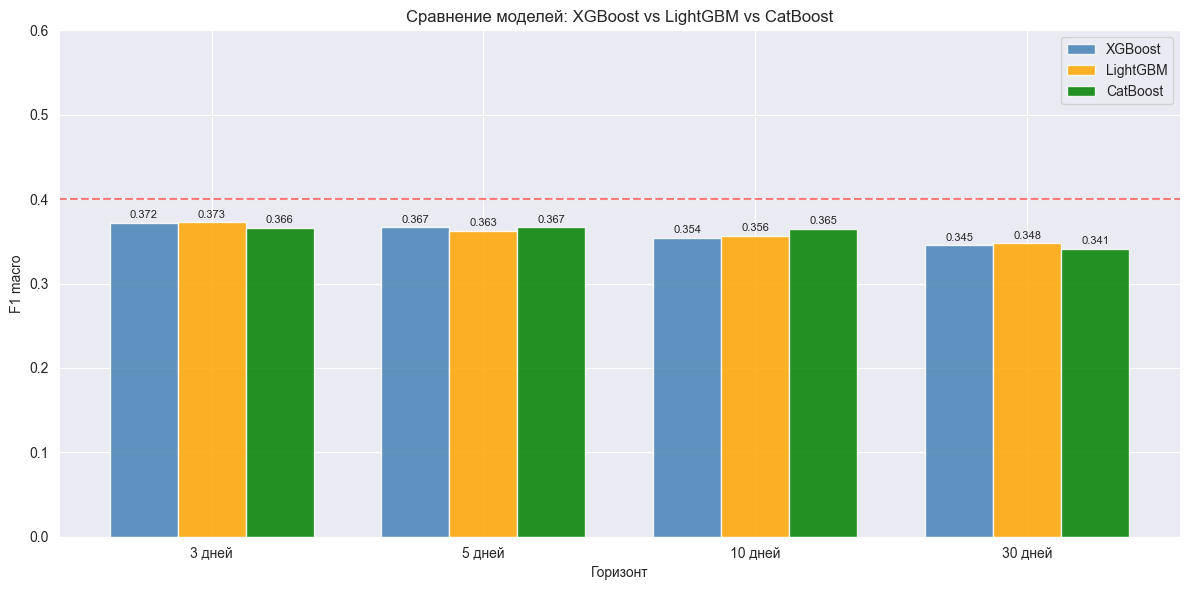

In [7]:
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(HORIZONS))
width = 0.25
colors = ["steelblue", "orange", "green"]

for i, model_name in enumerate(["XGBoost", "LightGBM", "CatBoost"]):
    values = [results[h][model_name] for h in HORIZONS]
    bars = ax.bar(x + i*width, values, width,
                  label=model_name, color=colors[i], alpha=0.85)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8)

ax.set_xlabel("Горизонт")
ax.set_ylabel("F1 macro")
ax.set_title("Сравнение моделей: XGBoost vs LightGBM vs CatBoost")
ax.set_xticks(x + width)
ax.set_xticklabels([f"{h} дней" for h in HORIZONS])
ax.legend()
ax.set_ylim(0, 0.6)
ax.axhline(0.4, color="red", linestyle="--", alpha=0.5, label="Целевой F1=0.4")

plt.tight_layout()
plt.savefig("../model/model_comparison.png", dpi=150)
plt.show()

In [8]:
# Найдём лучшую модель по среднему F1
avg_f1 = {name: np.mean([results[h][name] for h in HORIZONS])
          for name in ["XGBoost", "LightGBM", "CatBoost"]}

best_name = max(avg_f1, key=avg_f1.get)
print(f"Лучшая модель: {best_name}")
print(f"Средний F1 macro: {avg_f1}")

Лучшая модель: LightGBM
Средний F1 macro: {'XGBoost': 0.359625, 'LightGBM': 0.35987500000000006, 'CatBoost': 0.359625}
